In [1]:
# Exercise 1: Coin Change Problem

# Define the coin denominations
coin_values = [200, 100, 50, 20, 10, 5, 2, 1]  # Coin values in pence
target_amount = 93  # Target amount in pence

def min_coins(coin_values, target_amount):
    # Initialize the number of coins needed
    num_coins = 0
    remaining_amount = target_amount

    # Iterate over each coin value
    for coin in coin_values:
        # While the remaining amount is greater than or equal to the coin value
        while remaining_amount >= coin:
            remaining_amount -= coin  # Subtract the coin value from the remaining amount
            num_coins += 1  # Increment the coin count

    return num_coins

# Calculate the minimum number of coins for the target amount
minimum_coins = min_coins(coin_values, target_amount)

# Display the result
print(f"The minimum number of coins needed to make {target_amount}p is: {minimum_coins}")


The minimum number of coins needed to make 93p is: 5


In [2]:
# Exercise 2: Step-by-Step Instructions to Find the Minimum Number of Coins

# Step 1: Define the coin denominations
coin_values = [200, 100, 50, 20, 10, 5, 2, 1]  # Coin values in pence

# Step 2: Define the target amount
target_amount = 93  # Target amount in pence

# Step 3: Initialize variables
num_coins = 0  # Counter for the number of coins used
remaining_amount = target_amount  # Amount left to make change

# Step 4: Iterate through the coin denominations
for coin in coin_values:
    # Step 4a: While the remaining amount is greater than or equal to the coin value
    while remaining_amount >= coin:
        # Step 4b: Subtract the coin value from the remaining amount
        remaining_amount -= coin
        # Step 4c: Increment the coin counter
        num_coins += 1

# Step 5: Output the result
print(f"The minimum number of coins needed to make {target_amount}p is: {num_coins}")

The minimum number of coins needed to make 93p is: 5


In [3]:
# Exercise 3: Coin Change Problem using Provided Python Script

def coin_change(coins, amount):
    # Step 1: Sort the coins in descending order
    coins.sort(reverse=True)

    # Step 2: Initialize variables
    coin_count = 0  # Variable to keep track of the total number of coins used
    change = []     # List to store the coins used

    # Step 3: Iterate through each coin
    for coin in coins:
        # Step 4: While the amount is greater than or equal to the coin value
        while amount >= coin:
            amount -= coin  # Subtract the coin value from the amount
            coin_count += 1  # Increment the coin count
            change.append(coin)  # Add the coin to the change list

        # Step 5: Check if the amount has been reduced to zero
        if amount == 0:
            print(f"Minimum number of coins required: {coin_count}")
            print("Coins used:", change)
            return  # Exit the function if change is made

    # Step 6: If the loop ends and amount is not zero, print a message
    print("Not possible to get the desired change with the coins.")

# Step 7: Define the list of available coins and the target amount
coins = [1, 2, 5, 10, 20, 50, 100, 200]  # List of available coins
amount = 93  # Amount for which we need to find the minimum number of coins

# Step 8: Call the coin_change function
coin_change(coins, amount)  # Corrected line with closing parenthesis

Minimum number of coins required: 5
Coins used: [50, 20, 20, 2, 1]


In [4]:
# Exercise 4: Experiment with different coins and amounts
def test_coin_change():
    test_cases = [
        ([1, 5, 10, 25], 37),  # Expected output: 3 coins (25, 10, 2)
        ([1, 2, 5, 10, 20], 47),  # Expected output: 5 coins (20, 20, 5, 2)
        ([1, 5, 10, 50], 63)  # Expected output: 4 coins (50, 10, 2, 1)
    ]

    for coins, amount in test_cases:
        print(f"\nTesting with coins: {coins} and amount: {amount}")
        coin_change(coins, amount)

# Run the test
test_coin_change()


Testing with coins: [1, 5, 10, 25] and amount: 37
Minimum number of coins required: 4
Coins used: [25, 10, 1, 1]

Testing with coins: [1, 2, 5, 10, 20] and amount: 47
Minimum number of coins required: 4
Coins used: [20, 20, 5, 2]

Testing with coins: [1, 5, 10, 50] and amount: 63
Minimum number of coins required: 5
Coins used: [50, 10, 1, 1, 1]


In [5]:
pip install networkx

In [6]:
# Exercise 7
import heapq
import matplotlib.pyplot as plt
import networkx as nx


# Class representing a node in the graph
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name
        self.heuristic_cost = heuristic_cost
        self.adjacent = {}
        self.parent = None
        self.g_cost = float("inf")

    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

In [7]:
# A* search algorithm
def astar_search(start, goal):
    open_list = []
    closed_set = set()

    start.g_cost = 0
    heapq.heappush(open_list, start)

    while open_list:
        current_node = heapq.heappop(open_list)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]


        closed_set.add(current_node)

        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cost

            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost:
                continue

            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
    return None


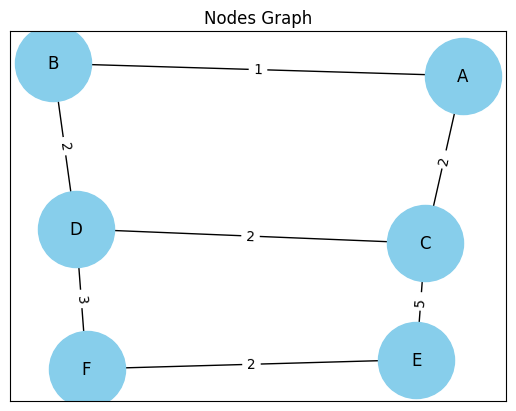

In [8]:
#Defining parameters

import matplotlib.pyplot as plt
import networkx as nx

# Define the Node class
class Node:
    def __init__(self, name, value):
        self.name = name
        self.value = value
        self.neighbors = {}  # Dictionary to hold neighbors and their costs

    def add_neighbor(self, neighbor, cost):
        self.neighbors[neighbor] = cost

# Creating nodes
A = Node("A", 5)
B = Node("B", 4)
C = Node("C", 3)
D = Node("D", 2)
E = Node("E", 1)
F = Node("F", 0)

# Adding neighbors and their costs
A.add_neighbor(B, 1)
A.add_neighbor(C, 2)
B.add_neighbor(D, 5)
C.add_neighbor(D, 2)
C.add_neighbor(E, 4)
D.add_neighbor(F, 3)
E.add_neighbor(F, 2)

# Visualization without the solution
G = nx.Graph()
edges = [
    (A.name, B.name, {'weight': 1}), (A.name, C.name, {'weight': 2}),
    (B.name, D.name, {'weight': 2}), (C.name, D.name, {'weight': 2}),
    (C.name, E.name, {'weight': 5}), (D.name, F.name, {'weight': 3}),
    (E.name, F.name, {'weight': 2}),
]
G.add_edges_from(edges)

# Draw the graph
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# Corrected title string
plt.title('Nodes Graph')
plt.show()

A* path: ['A', 'C', 'D', 'F']


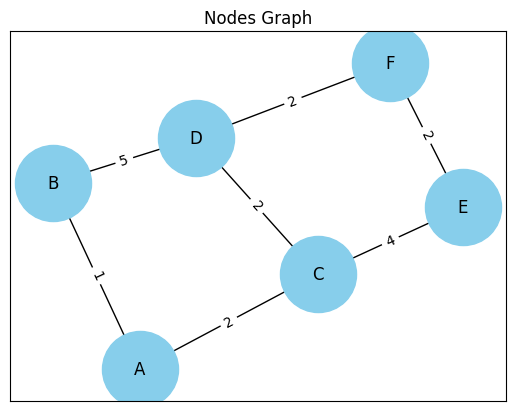

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
import heapq

# Define the Node class
class Node:
    def __init__(self, name, value):
        self.name = name
        self.value = value
        self.neighbors = {}  # Dictionary to hold neighbors and their costs
        self.g_cost = float('inf')  # Cost from start to this node
        self.h_cost = 0  # Heuristic cost to goal
        self.f_cost = float('inf')  # Total cost
        self.parent = None  # To reconstruct the path

    def add_neighbor(self, neighbor, cost):
        self.neighbors[neighbor] = cost

    def __lt__(self, other):
        return self.f_cost < other.f_cost  # Compare based on f_cost

# A* search algorithm
def astar_search(start, goal):
    open_set = []
    closed_set = set()

    start.g_cost = 0
    start.f_cost = start.h_cost  # Assuming h_cost is set externally
    heapq.heappush(open_set, (start.f_cost, start))

    while open_set:
        current_node = heapq.heappop(open_set)[1]

        if current_node == goal:
            path = []
            while current_node:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]  # Return reversed path

        closed_set.add(current_node)

        for neighbor, cost in current_node.neighbors.items():
            if neighbor in closed_set:
                continue

            tentative_g_cost = current_node.g_cost + cost

            if tentative_g_cost < neighbor.g_cost:
                neighbor.parent = current_node
                neighbor.g_cost = tentative_g_cost
                neighbor.f_cost = neighbor.g_cost + neighbor.h_cost

                if neighbor not in [i[1] for i in open_set]:
                    heapq.heappush(open_set, (neighbor.f_cost, neighbor))

    return None  # Return None if no path is found

# Creating nodes
A = Node("A", 5)
B = Node("B", 4)
C = Node("C", 3)
D = Node("D", 2)
E = Node("E", 1)
F = Node("F", 0)

# Adding neighbors and their costs
A.add_neighbor(B, 1)
A.add_neighbor(C, 2)
B.add_neighbor(D, 5)
C.add_neighbor(D, 2)
C.add_neighbor(E, 4)
D.add_neighbor(F, 3)
E.add_neighbor(F, 2)

# Set heuristic costs (h_cost) for each node (example values)
A.h_cost = 5  # Example heuristic cost to goal
B.h_cost = 4
C.h_cost = 3
D.h_cost = 1
E.h_cost = 1
F.h_cost = 0  # Goal node

# Running the A* search algorithm
path = astar_search(A, F)
print("A* path:", path)

# Visualization of the graph (optional)
G = nx.Graph()
edges = [
    (A.name, B.name, {'weight': 1}),
    (B.name, D.name, {'weight': 5}),
    (C.name, E.name, {'weight': 4}),
    (E.name, F.name, {'weight': 2}),
    (A.name, C.name, {'weight': 2}),
    (C.name, D.name, {'weight': 2}),
    (D.name, F.name, {'weight': 2})
]
G.add_edges_from(edges)

# Draw the graph
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('Nodes Graph')
plt.show()

A* path: ['A', 'C', 'D', 'F']


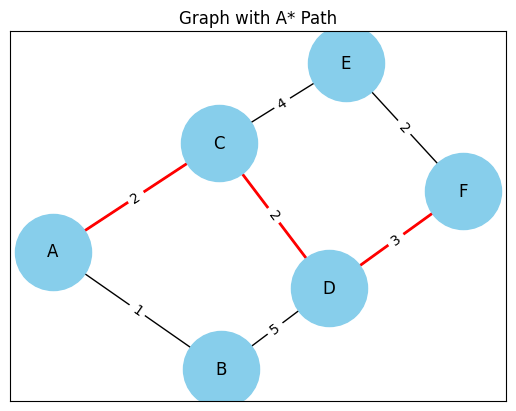

In [10]:
import matplotlib.pyplot as plt
import networkx as nx
import heapq

# Define the Node class
class Node:
    def __init__(self, name, value):
        self.name = name
        self.value = value
        self.neighbors = {}  # Dictionary to hold neighbors and their costs
        self.g_cost = float('inf')  # Cost from start to this node
        self.h_cost = 0  # Heuristic cost to goal
        self.f_cost = float('inf')  # Total cost
        self.parent = None  # To reconstruct the path

    def add_neighbor(self, neighbor, cost):
        self.neighbors[neighbor] = cost

    def __lt__(self, other):
        return self.f_cost < other.f_cost  # Compare based on f_cost

# A* search algorithm
def astar_search(start, goal):
    open_set = []
    closed_set = set()

    start.g_cost = 0
    start.f_cost = start.h_cost  # Assuming h_cost is set externally
    heapq.heappush(open_set, (start.f_cost, start))

    while open_set:
        current_node = heapq.heappop(open_set)[1]

        if current_node == goal:
            path = []
            while current_node:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]  # Return reversed path

        closed_set.add(current_node)

        for neighbor, cost in current_node.neighbors.items():
            if neighbor in closed_set:
                continue

            tentative_g_cost = current_node.g_cost + cost

            if tentative_g_cost < neighbor.g_cost:
                neighbor.parent = current_node
                neighbor.g_cost = tentative_g_cost
                neighbor.f_cost = neighbor.g_cost + neighbor.h_cost

                if neighbor not in [i[1] for i in open_set]:
                    heapq.heappush(open_set, (neighbor.f_cost, neighbor))

    return None  # Return None if no path is found

# Creating nodes
A = Node("A", 5)
B = Node("B", 4)
C = Node("C", 3)
D = Node("D", 2)
E = Node("E", 1)
F = Node("F", 0)

# Adding neighbors and their costs
A.add_neighbor(B, 1)
A.add_neighbor(C, 2)
B.add_neighbor(D, 5)
C.add_neighbor(D, 2)
C.add_neighbor(E, 4)
D.add_neighbor(F, 3)
E.add_neighbor(F, 2)

# Set heuristic costs (h_cost) for each node (example values)
A.h_cost = 5  # Example heuristic cost to goal
B.h_cost = 4
C.h_cost = 3
D.h_cost = 1
E.h_cost = 1
F.h_cost = 0  # Goal node

# Running the A* search algorithm
path = astar_search(A, F)
print("A* path:", path)

# Visualization of the graph
G = nx.Graph()
edges = [
    (A.name, B.name, {'weight': 1}),
    (A.name, C.name, {'weight': 2}),
    (B.name, D.name, {'weight': 5}),
    (C.name, D.name, {'weight': 2}),
    (C.name, E.name, {'weight': 4}),
    (D.name, F.name, {'weight': 3}),
    (E.name, F.name, {'weight': 2})
]
G.add_edges_from(edges)

# Draw the graph
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')

# Highlight the A* path
if path:  # Check if a path was found
    nx.draw_networkx_edges(G, pos, edgelist=[(path[i], path[i + 1]) for i in range(len(path) - 1)], edge_color='r', width=2)

# Draw edge labels
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# Set title and show the plot
plt.title('Graph with A* Path')
plt.show()

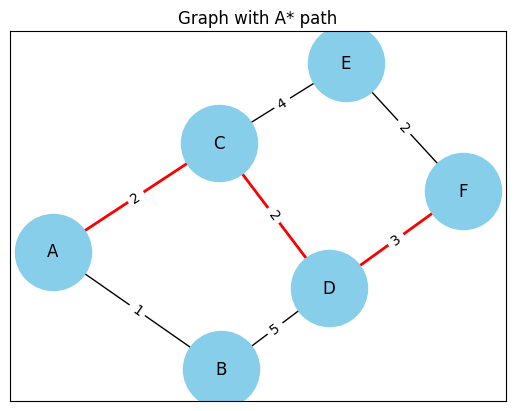

In [11]:
#Visualization with A* path
plt.title('Graph with A* path')
nx.draw_networkx(G, pos, with_labels=True, node_size=3000,
node_color='skyblue')
nx.draw_networkx_edges(G, pos, edgelist=[(path[i], path[i + 1]) for i in
range(len(path) - 1)], edge_color='r', width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()

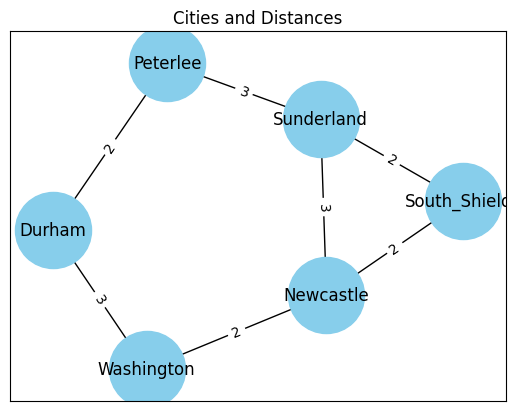

Optimal Path from Sunderland to Washington: ['Sunderland', 'South_Shields', 'Newcastle', 'Washington']


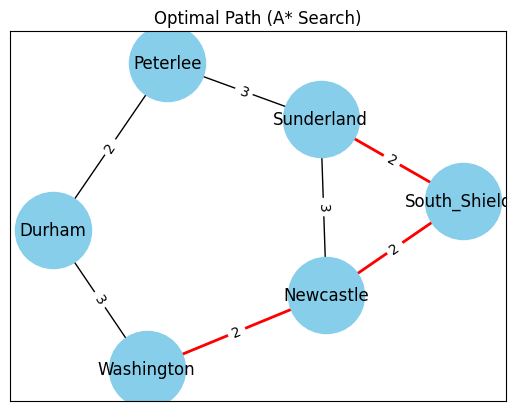

In [12]:
#Exercise 8
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# Define the Node class
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name
        self.heuristic_cost = heuristic_cost  # Estimated cost to goal (h-value)
        self.adjacent = {}  # Neighbors with edge costs
        self.parent = None  # For reconstructing the path
        self.g_cost = float("inf")  # Cost from start to this node (g-value)

    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

# A* Search Algorithm
def astar_search(start, goal):
    open_list = []
    closed_set = set()

    start.g_cost = 0
    heapq.heappush(open_list, start)

    while open_list:
        current_node = heapq.heappop(open_list)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]  # Reverse the path to get start-to-goal order

        closed_set.add(current_node)

        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cost

            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost:
                continue

            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
    return None  # No path found

# Define Nodes (Cities)
sunderland = Node("Sunderland", 7)  # Example heuristic value to Washington
peterlee = Node("Peterlee", 6)
durham = Node("Durham", 5)
washington = Node("Washington", 0)  # Corrected spelling
newcastle = Node("Newcastle", 4)
south_shields = Node("South_Shields", 2)

# Add Neighbors and Distances
sunderland.add_neighbor(south_shields, 2)
sunderland.add_neighbor(peterlee, 3)
south_shields.add_neighbor(newcastle, 2)
newcastle.add_neighbor(washington, 2)
newcastle.add_neighbor(sunderland, 3)
washington.add_neighbor(durham, 3)
durham.add_neighbor(peterlee, 2)
peterlee.add_neighbor(sunderland, 3)

# Visualize the Graph
G = nx.Graph()
edges = [
    ("Sunderland", "South_Shields", {'weight': 2}),
    ("Sunderland", "Peterlee", {'weight': 3}),
    ("South_Shields", "Newcastle", {'weight': 2}),
    ("Newcastle", "Washington", {'weight': 2}),  # Corrected spelling
    ("Newcastle", "Sunderland", {'weight': 3}),
    ("Washington", "Durham", {'weight': 3}),
    ("Durham", "Peterlee", {'weight': 2}),
    ("Peterlee", "Sunderland", {'weight': 3})
]
G.add_edges_from(edges)

# Initial visualization of the graph
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Cities and Distances")
plt.show()

# Running the A* Search Algorithm
path = astar_search(sunderland, washington)
if path:
    print("Optimal Path from Sunderland to Washington:", path)
else:
    print("No path found from Sunderland to Washington")

# Visualize the Solution Path
if path:
    plt.title("Optimal Path (A* Search)")
    nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')
    nx.draw_networkx_edges(
        G, pos, edgelist=[(path[i], path[i + 1]) for i in range(len(path) - 1)], edge_color='r', width=2
    )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()

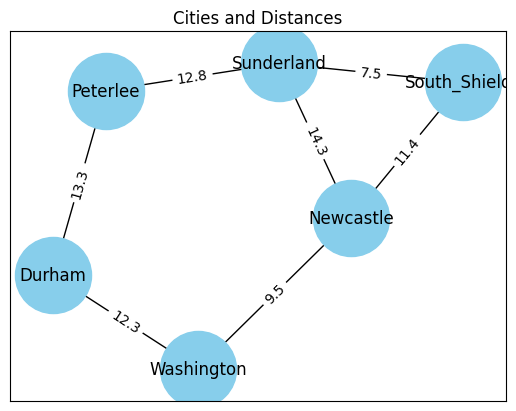

Optimal Path from Sunderland to Washington: ['Sunderland', 'South_Shields', 'Newcastle', 'Washington']


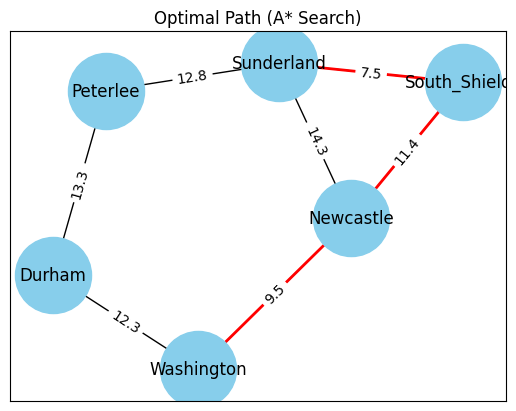

In [13]:
#Exercise 9
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# Define the Node class
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name
        self.heuristic_cost = heuristic_cost  # Estimated cost to goal (h-value)
        self.adjacent = {}  # Neighbors with edge costs
        self.parent = None  # For reconstructing the path
        self.g_cost = float("inf")  # Cost from start to this node (g-value)

    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

# A* Search Algorithm
def astar_search(start, goal):
    open_list = []
    closed_set = set()

    start.g_cost = 0
    heapq.heappush(open_list, start)

    while open_list:
        current_node = heapq.heappop(open_list)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]  # Reverse the path to get start-to-goal order

        closed_set.add(current_node)

        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cost

            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost:
                continue

            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
    return None  # No path found

# Define Nodes (Cities)
sunderland = Node("Sunderland", 7)  # Example heuristic value to Washington
peterlee = Node("Peterlee", 6)
durham = Node("Durham", 5)
washington = Node("Washington", 0)  # Corrected spelling
newcastle = Node("Newcastle", 4)
south_shields = Node("South_Shields", 2)

# Add Neighbors and Distances
sunderland.add_neighbor(south_shields, 7.5)
sunderland.add_neighbor(peterlee, 13.6)
south_shields.add_neighbor(newcastle, 11.4)
newcastle.add_neighbor(washington, 9.5)
newcastle.add_neighbor(sunderland, 14.3)
washington.add_neighbor(durham, 12.3)
durham.add_neighbor(peterlee, 13.3)
peterlee.add_neighbor(sunderland, 12.8)

# Visualize the Graph
G = nx.Graph()
edges = [
    ("Sunderland", "South_Shields", {'weight': 7.5}),
    ("Sunderland", "Peterlee", {'weight': 13.6}),
    ("South_Shields", "Newcastle", {'weight': 11.4}),
    ("Newcastle", "Washington", {'weight': 9.5}),  # Corrected spelling
    ("Newcastle", "Sunderland", {'weight': 14.3}),
    ("Washington", "Durham", {'weight': 12.3}),
    ("Durham", "Peterlee", {'weight': 13.3}),
    ("Peterlee", "Sunderland", {'weight': 12.8})
]
G.add_edges_from(edges)

# Initial visualization of the graph
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Cities and Distances")
plt.show()

# Running the A* Search Algorithm
path = astar_search(sunderland, washington)
if path:
    print("Optimal Path from Sunderland to Washington:", path)
else:
    print("No path found from Sunderland to Washington")

# Visualize the Solution Path
if path:
    plt.title("Optimal Path (A* Search)")
    nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')
    nx.draw_networkx_edges(
        G, pos, edgelist=[(path[i], path[i + 1]) for i in range(len(path) - 1)], edge_color='r', width=2
    )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()


In [14]:
#Exercise 10
# Import required libraries
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# Define the Node class
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name  # Name of the city
        self.heuristic_cost = heuristic_cost  # Estimated cost to goal (h-value)
        self.adjacent = {}  # Dictionary to store neighbors and distances
        self.parent = None  # For reconstructing the path
        self.g_cost = float("inf")  # Cost from start to this node (g-value)

    # Add a neighbor with its associated cost
    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    # Define comparison for priority queue (based on total cost)
    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

# A* Search Algorithm
def astar_search(start, goal):
    """
    Performs A* Search to find the shortest path from start to goal.
    :param start: Starting node
    :param goal: Goal node
    :return: List of node names representing the optimal path
    """
    open_list = []  # Priority queue to store nodes to be explored
    closed_set = set()  # Set to store already explored nodes

    start.g_cost = 0  # Initialize the starting node's cost to 0
    heapq.heappush(open_list, start)  # Add starting node to the open list

    while open_list:
        # Pop the node with the lowest cost (g_cost + h_cost)
        current_node = heapq.heappop(open_list)

        # If we reach the goal, reconstruct the path
        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]  # Reverse to get start-to-goal order

        # Mark the current node as explored
        closed_set.add(current_node)

        # Explore each neighbor of the current node
        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cos


In [15]:
import random
# Number of individuals in each generation
POPULATION_SIZE = 4
# Valid genes
GENES = '''01'''
# Target string to be generated
TARGET = "001010"


In [16]:
class Individual(object):
        #Class representing individual in population
        def __init__(self, chromosome):
            self.chromosome = chromosome
            self.fitness = self.cal_fitness()
        @classmethod
        def mutated_genes(self):
            #create random genes for mutation
            global GENES
            gene = random.choice(GENES)
            return gene
        @classmethod
        def create_gnome(self):
            #create chromosome or string of genes
            global TARGET
            gnome_len = len(TARGET)
            return [self.mutated_genes() for _ in range(gnome_len)]
        def mate(self, par2):
            #Perform mating and produce new offspring
            # chromosome for offspring
            child_chromosome = []
            for gp1, gp2 in zip(self.chromosome, par2.chromosome):
                # random probability
                prob = random.random()
                # if prob is less than 0.45, insert gene from parent 1
                if prob < 0.45:
                    child_chromosome.append(gp1)
                # if prob is between 0.45 and 0.90, insert gene from parent 2
                elif prob < 0.90:
                    child_chromosome.append(gp2)
                # otherwise insert random gene(mutate),
                # for maintaining diversity
                else:
                    child_chromosome.append(self.mutated_genes())
            # create new Individual(offspring) using generated chromosome for offspring
            return Individual(child_chromosome)
        def cal_fitness(self):
            ''' Calculate fitness score, it is the number of characters in string
which differ from target string. '''
            global TARGET
            fitness = 0
            for gs, gt in zip(self.chromosome, TARGET):
                if gs != gt: fitness+= 1
            return fitness


In [17]:
# Driver code
def main():
    global POPULATION_SIZE
    # Use global POPULATION_SIZE variable
    # Current generation counter
    generation = 1
    found = False  # Flag to check if the target is found
    population = []  # List to hold the current population
    # Create the initial population
    for _ in range(POPULATION_SIZE):
                gnome = Individual.create_gnome()  # Generate a random chromosome
                population.append(Individual(gnome))  # Add the individual to the population
    # Evolve the population until the target string is found
    while not found:
        # Sort the population by fitness (lower fitness is better)
        population = sorted(population, key=lambda x:x.fitness)
        # if the individual having lowest fitness score ie.
        # 0 then we know that we have reached to the target
        # and break the loop
        if population[0].fitness <= 0:
            found = True
            break
        # Otherwise generate new offsprings for new generation
        new_generation = []

        ## Perform Elitism, that mean 10% of fittest population
        # goes to the next generation
        s = int((10*POPULATION_SIZE)/100)
        new_generation.extend(population[:s])

        # From 50% of fittest population, Individuals
        # will mate to produce offspring
        s = int((90 * POPULATION_SIZE) / 100)
        for _ in range(s):
            # Select parents randomly from the top 50% of the population
            parent1 = random.choice(population[:50])
            parent2 = random.choice(population[:50])
            # Create offspring through mating
            child = parent1.mate(parent2)
            new_generation.append(child)

        # Update the population for the next generation
        population = new_generation

        # Print the details of the current generation
        print("Generation: {}\tString: {}\tFitness: {}".format(
            generation,
            "".join(population[0].chromosome),  # Fittest individual's chromosome
            population[0].fitness))
        generation += 1  # Increment generation counter
    # Print the final generation details
    print("Generation: {}\tString: {}\tFitness: {}".format(generation,
        "".join(population[0].chromosome),
        population[0].fitness))
# Run the program
if __name__ == '__main__':
    main()


Generation: 1	String: 101110	Fitness: 2
Generation: 2	String: 101110	Fitness: 2
Generation: 3	String: 100010	Fitness: 2
Generation: 4	String: 100010	Fitness: 2
Generation: 5	String: 110010	Fitness: 3
Generation: 6	String: 111000	Fitness: 3
Generation: 7	String: 100011	Fitness: 3
Generation: 8	String: 111000	Fitness: 3
Generation: 9	String: 111000	Fitness: 3
Generation: 10	String: 111100	Fitness: 4
Generation: 11	String: 111000	Fitness: 3
Generation: 12	String: 011000	Fitness: 2
Generation: 13	String: 011000	Fitness: 2
Generation: 14	String: 011001	Fitness: 3
Generation: 15	String: 011010	Fitness: 1
Generation: 16	String: 011110	Fitness: 2
Generation: 17	String: 011111	Fitness: 3
Generation: 18	String: 011110	Fitness: 2
Generation: 19	String: 011010	Fitness: 1
Generation: 20	String: 001010	Fitness: 0


In [18]:
import random

# Define global variables
POPULATION_SIZE = 100  # Size of the population
GENES = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789!@#$%^&*()-=_+[]{}|;:,.<>?/~`"  # All alphabets, spaces, and special characters
TARGET = "Welcome to AI"  # Updated target string

class Individual:
    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = self.cal_fitness()  # Calculate fitness upon initialization

    @classmethod
    def mutated_genes(self):
        """Create random genes for mutation."""
        global GENES
        gene = random.choice(GENES)
        return gene

    @classmethod
    def create_gnome(self):
        """Create chromosome or string of genes."""
        global TARGET
        gnome_len = len(TARGET)  # Length of the target string
        return [self.mutated_genes() for _ in range(gnome_len)]  # Create random genes for the chromosome

    def mate(self, par2):
        """Perform mating and produce new offspring."""
        child_chromosome = []
        for gp1, gp2 in zip(self.chromosome, par2.chromosome):
            prob = random.random()

            # Select genes from parent 1, parent 2, or mutate
            if prob < 0.45:
                child_chromosome.append(gp1)
            elif prob < 0.90:
                child_chromosome.append(gp2)
            else:
                child_chromosome.append(self.mutated_genes())

        return Individual(child_chromosome)

    def cal_fitness(self):
        """Calculate fitness score (number of differing characters)."""
        global TARGET
        fitness = 0
        for gs, gt in zip(self.chromosome, TARGET):
            if gs != gt:
                fitness += 1
        return fitness

# Driver code
def main():
    global POPULATION_SIZE

    # Current generation counter
    generation = 1
    found = False  # Flag to check if the target is found
    population = []  # List to hold the current population

    # Create the initial population
    for _ in range(POPULATION_SIZE):
        gnome = Individual.create_gnome()  # Generate a random chromosome
        population.append(Individual(gnome))  # Add the individual to the population

    # Evolve the population until the target string is found
    while not found:
        # Sort the population by fitness (lower fitness is better)
        population = sorted(population, key=lambda x: x.fitness)

        # If the individual having lowest fitness score is 0, then we have reached the target
        if population[0].fitness <= 0:
            found = True
            break

        # Otherwise, generate new offsprings for the next generation
        new_generation = []

        # Perform Elitism: 10% of the fittest population goes to the next generation
        s = int((10 * POPULATION_SIZE) / 100)
        new_generation.extend(population[:s])

        # From 90% of the fittest population, individuals will mate to produce offspring
        s = int((90 * POPULATION_SIZE) / 100)
        for _ in range(s):
            # Select parents randomly from the top 50% of the population
            parent1 = random.choice(population[:50])
            parent2 = random.choice(population[:50])
            # Create offspring through mating
            child = parent1.mate(parent2)
            new_generation.append(child)

        # Update the population for the next generation
        population = new_generation

        # Print the details of the current generation
        print("Generation: {}\tString: {}\tFitness: {}".format(
            generation,
            "".join(population[0].chromosome),  # Fittest individual's chromosome
            population[0].fitness))  # Fittest individual's fitness
        generation += 1  # Increment generation counter

    # Print the final generation details
    print("Generation: {}\tString: {}\tFitness: {}".format(
        generation,
        "".join(population[0].chromosome),
        population[0].fitness))

# Run the program
if __name__ == '__main__':
    main()


Generation: 1	String: nSx}+me=t#7FX	Fitness: 10
Generation: 2	String: nSx}+me=t#7FX	Fitness: 10
Generation: 3	String: nSx}+me=t#7FX	Fitness: 10
Generation: 4	String: nSx}+me=t#7FX	Fitness: 10
Generation: 5	String: Ke } me.t1.gK	Fitness: 9
Generation: 6	String: nex}+me t#SbX	Fitness: 8
Generation: 7	String: We c+meyt#7)M	Fitness: 7
Generation: 8	String: We c+meyt#7)M	Fitness: 7
Generation: 9	String: fexcome t#BbJ	Fitness: 6
Generation: 10	String: fexcome t#BbJ	Fitness: 6
Generation: 11	String: fexcome t#BbJ	Fitness: 6
Generation: 12	String: We c+me t)UA$	Fitness: 5
Generation: 13	String: We c+me t)UA$	Fitness: 5
Generation: 14	String: We c+me t)UA$	Fitness: 5
Generation: 15	String: We c+me t)UA$	Fitness: 5
Generation: 16	String: Wexcome t2AA^	Fitness: 4
Generation: 17	String: Wexcome t2AA^	Fitness: 4
Generation: 18	String: Wexcome t2AA^	Fitness: 4
Generation: 19	String: Wexcome t2AA^	Fitness: 4
Generation: 20	String: Wexcome t2AA^	Fitness: 4
Generation: 21	String: Wexcome t2AA^	Fitness:

In [19]:
# Exercise 13
import random
import time  # Import time module to measure duration

# Define global variables
POPULATION_SIZE = 100  # Size of the population
GENES = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789!@#$%^&*()-=_+[]{}|;:,.<>?/~`"  # All alphabets, spaces, and special characters
TARGET = "Welcome to AI"  # Updated target string

class Individual:
    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = self.cal_fitness()  # Calculate fitness upon initialization

    @classmethod
    def mutated_genes(self):
        """Create random genes for mutation."""
        global GENES
        gene = random.choice(GENES)
        return gene

    @classmethod
    def create_gnome(self):
        """Create chromosome or string of genes."""
        global TARGET
        gnome_len = len(TARGET)  # Length of the target string
        return [self.mutated_genes() for _ in range(gnome_len)]  # Create random genes for the chromosome

    def mate(self, par2):
        """Perform mating and produce new offspring."""
        child_chromosome = []
        for gp1, gp2 in zip(self.chromosome, par2.chromosome):
            prob = random.random()

            # Select genes from parent 1, parent 2, or mutate
            if prob < 0.45:
                child_chromosome.append(gp1)
            elif prob < 0.90:
                child_chromosome.append(gp2)
            else:
                child_chromosome.append(self.mutated_genes())

        return Individual(child_chromosome)

    def cal_fitness(self):
        """Calculate fitness score (number of differing characters)."""
        global TARGET
        fitness = 0
        for gs, gt in zip(self.chromosome, TARGET):
            if gs != gt:
                fitness += 1
        return fitness

# Driver code
def main():
    global POPULATION_SIZE

    # Record start time
    start_time = time.time()

    # Current generation counter
    generation = 1
    found = False  # Flag to check if the target is found
    population = []  # List to hold the current population

    # Create the initial population
    for _ in range(POPULATION_SIZE):
        gnome = Individual.create_gnome()  # Generate a random chromosome
        population.append(Individual(gnome))  # Add the individual to the population

    # Evolve the population until the target string is found
    while not found:
        # Sort the population by fitness (lower fitness is better)
        population = sorted(population, key=lambda x: x.fitness)

        # If the individual having the lowest fitness score is 0, then we have reached the target
        if population[0].fitness <= 0:
            found = True
            break

        # Otherwise, generate new offsprings for the next generation
        new_generation = []

        # Perform Elitism: 10% of the fittest population goes to the next generation
        s = int((10 * POPULATION_SIZE) / 100)
        new_generation.extend(population[:s])

        # From 90% of the fittest population, individuals will mate to produce offspring
        s = int((90 * POPULATION_SIZE) / 100)
        for _ in range(s):
            # Select parents randomly from the top 50% of the population
            parent1 = random.choice(population[:50])
            parent2 = random.choice(population[:50])
            # Create offspring through mating
            child = parent1.mate(parent2)
            new_generation.append(child)

        # Update the population for the next generation
        population = new_generation

        # Print the details of the current generation
        print("Generation: {}\tString: {}\tFitness: {}".format(
            generation,
            "".join(population[0].chromosome),  # Fittest individual's chromosome
            population[0].fitness))  # Fittest individual's fitness
        generation += 1  # Increment generation counter

    # Print the final generation details
    print("Generation: {}\tString: {}\tFitness: {}".format(
        generation,
        "".join(population[0].chromosome),
        population[0].fitness))

    # Measure the duration taken
    end_time = time.time()
    duration = end_time - start_time
    print(f"Time taken to find the solution: {duration:.4f} seconds")

# Run the program
if __name__ == '__main__':
    main()


Generation: 1	String: ]H|cWk^|NsY>[	Fitness: 12
Generation: 2	String: .j|cWGw mMd3A	Fitness: 11
Generation: 3	String: /becNGe >vd~5	Fitness: 10
Generation: 4	String: /becNGe >vd~5	Fitness: 10
Generation: 5	String: WWtcDGe jvIeI	Fitness: 8
Generation: 6	String: WWtcDGe jvIeI	Fitness: 8
Generation: 7	String: WWtcDGe jvIeI	Fitness: 8
Generation: 8	String: Je?cNGe t|[AI	Fitness: 6
Generation: 9	String: Je?cNGe t|[AI	Fitness: 6
Generation: 10	String: Je?cNGe t|[AI	Fitness: 6
Generation: 11	String: Welc!Ge >0;AI	Fitness: 5
Generation: 12	String: WelcNGe t8[AI	Fitness: 4
Generation: 13	String: WelcNGe t8[AI	Fitness: 4
Generation: 14	String: WelcNGe t8[AI	Fitness: 4
Generation: 15	String: WelcNGe t8[AI	Fitness: 4
Generation: 16	String: WelcNGe t8[AI	Fitness: 4
Generation: 17	String: WelcNGe t8[AI	Fitness: 4
Generation: 18	String: WelcNGe t8[AI	Fitness: 4
Generation: 19	String: WelcNGe t8[AI	Fitness: 4
Generation: 20	String: WelcNGe t8[AI	Fitness: 4
Generation: 21	String: Welc@Fe touAI	Fitness:

In [20]:
# Exercise 14
import random
import time  # Import the time module to measure duration

# Define global variables
POPULATION_SIZE = 100  # Size of the population
GENES = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789!@#$%^&*()-=_+[]{}|;:,.<>?/~`"  # All alphabets, spaces, and special characters
TARGET = "Welcome to the world of AI programming"  # Updated target with 5 words

class Individual:
    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = self.cal_fitness()  # Calculate fitness upon initialization

    @classmethod
    def mutated_genes(self):
        """Create random genes for mutation."""
        global GENES
        gene = random.choice(GENES)
        return gene

    @classmethod
    def create_gnome(self):
        """Create chromosome or string of genes."""
        global TARGET
        gnome_len = len(TARGET)  # Length of the target string
        return [self.mutated_genes() for _ in range(gnome_len)]  # Create random genes for the chromosome

    def mate(self, par2):
        """Perform mating and produce new offspring."""
        child_chromosome = []
        for gp1, gp2 in zip(self.chromosome, par2.chromosome):
            prob = random.random()

            # Select genes from parent 1, parent 2, or mutate
            if prob < 0.45:
                child_chromosome.append(gp1)
            elif prob < 0.90:
                child_chromosome.append(gp2)
            else:
                child_chromosome.append(self.mutated_genes())

        return Individual(child_chromosome)

    def cal_fitness(self):
        """Calculate fitness score (number of differing characters)."""
        global TARGET
        fitness = 0
        for gs, gt in zip(self.chromosome, TARGET):
            if gs != gt:
                fitness += 1
        return fitness

# Driver code
def main():
    global POPULATION_SIZE

    # Record the start time
    start_time = time.time()  # Start timer

    # Current generation counter
    generation = 1
    found = False  # Flag to check if the target is found
    population = []  # List to hold the current population

    # Create the initial population
    for _ in range(POPULATION_SIZE):
        gnome = Individual.create_gnome()  # Generate a random chromosome
        population.append(Individual(gnome))  # Add the individual to the population

    # Evolve the population until the target string is found
    while not found:
        # Sort the population by fitness (lower fitness is better)
        population = sorted(population, key=lambda x: x.fitness)

        # If the individual having the lowest fitness score is 0, then we have reached the target
        if population[0].fitness <= 0:
            found = True
            break

        # Otherwise, generate new offsprings for the next generation
        new_generation = []

        # Perform Elitism: 10% of the fittest population goes to the next generation
        s = int((10 * POPULATION_SIZE) / 100)
        new_generation.extend(population[:s])

        # From 90% of the fittest population, individuals will mate to produce offspring
        s = int((90 * POPULATION_SIZE) / 100)
        for _ in range(s):
            # Select parents randomly from the top 50% of the population
            parent1 = random.choice(population[:50])
            parent2 = random.choice(population[:50])
            # Create offspring through mating
            child = parent1.mate(parent2)
            new_generation.append(child)

        # Update the population for the next generation
        population = new_generation

        # Debug: Print the progress of the current generation
        print(f"Generation: {generation}\tString: {''.join(population[0].chromosome)}\tFitness: {population[0].fitness}")

        # Increment generation counter
        generation += 1

    # Record the end time once the solution is found
    end_time = time.time()  # End timer

    # Print the final generation details
    print(f"Generation: {generation}\tString: {''.join(population[0].chromosome)}\tFitness: {population[0].fitness}")

    # Calculate and print the duration (time taken to find the solution)
    duration = end_time - start_time
    print(f"Time taken to find the solution: {duration:.6f} seconds")

# Run the program
if __name__ == '__main__':
    main()


Generation: 1	String: !9Jh6=><q*,Q@2vJYx|FToY`Q]dD;&dbJB;un^	Fitness: 36
Generation: 2	String: T_l0-mq]rQt$L;7-[ O70mfg3M`.t9A4==V{lh	Fitness: 35
Generation: 3	String: b)lnMkV5_4iPla aU{$ZEo42k=hv0D-kYi)5n9	Fitness: 34
Generation: 4	String: b)lnMkV5_4iPla aU{$ZEo42k=hv0D-kYi)5n9	Fitness: 34
Generation: 5	String: Q;lBPm4]k3&$.ema[dv:t2fCeM`2LkAr={>KD~	Fitness: 33
Generation: 6	String: 4Dlh#m@]tA*$Lprfv=6zu`fgkIZ..oD*=>VK}h	Fitness: 32
Generation: 7	String: b2l9#uFdf_M,be tmdrZxL~sk])Drog9[5;nng	Fitness: 30
Generation: 8	String: b2l9#uFdf_M,be tmdrZxL~sk])Drog9[5;nng	Fitness: 30
Generation: 9	String: ++luB40It_mofe w}XQ$U`iYQ:4bro)eJ Qzng	Fitness: 29
Generation: 10	String: /+l+#m0ltGqQfe 5m(#Qro}KQ:0Bro|2Z5e:ng	Fitness: 28
Generation: 11	String: /+l+#m0ltGqQfe 5m(#Qro}KQ:0Bro|2Z5e:ng	Fitness: 28
Generation: 12	String: /+A;#m|.t%q$he wt #d7o}`^IR.rDgAZ5):ng	Fitness: 25
Generation: 13	String: /+A;#m|.t%q$he wt #d7o}`^IR.rDgAZ5):ng	Fitness: 25
Generation: 14	String: Q7l+Qm`!i%XQhe wtZQdvops

In [ ]:
# Exercise 15
import random
import time  # Import the time module to measure duration

# Define global variables
POPULATION_SIZE = 100  # Size of the population
GENES = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"  # Letters (lowercase and uppercase) and numbers
TARGET = "Welcome to the world of AI programming"  # Updated target with 5 words

class Individual:
    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = self.cal_fitness()  # Calculate fitness upon initialization

    @classmethod
    def mutated_genes(self):
        """Create random genes for mutation."""
        global GENES
        gene = random.choice(GENES)
        return gene

    @classmethod
    def create_gnome(self):
        """Create chromosome or string of genes."""
        global TARGET
        gnome_len = len(TARGET)  # Length of the target string
        return [self.mutated_genes() for _ in range(gnome_len)]  # Create random genes for the chromosome

    def mate(self, par2):
        """Perform mating and produce new offspring."""
        child_chromosome = []
        for gp1, gp2 in zip(self.chromosome, par2.chromosome):
            prob = random.random()

            # Select genes from parent 1, parent 2, or mutate
            if prob < 0.45:
                child_chromosome.append(gp1)
            elif prob < 0.90:
                child_chromosome.append(gp2)
            else:
                child_chromosome.append(self.mutated_genes())

        return Individual(child_chromosome)

    def cal_fitness(self):
        """Calculate fitness score (number of differing characters)."""
        global TARGET
        fitness = 0
        for gs, gt in zip(self.chromosome, TARGET):
            if gs != gt:
                fitness += 1
        return fitness

# Driver code
def main():
    global POPULATION_SIZE

    # Record the start time
    start_time = time.time()  # Start timer

    # Current generation counter
    generation = 1
    found = False  # Flag to check if the target is found
    population = []  # List to hold the current population

    # Create the initial population
    for _ in range(POPULATION_SIZE):
        gnome = Individual.create_gnome()  # Generate a random chromosome
        population.append(Individual(gnome))  # Add the individual to the population

    # Evolve the population until the target string is found
    while not found:
        # Sort the population by fitness (lower fitness is better)
        population = sorted(population, key=lambda x: x.fitness)

        # If the individual having the lowest fitness score is 0, then we have reached the target
        if population[0].fitness <= 0:
            found = True
            break

        # Otherwise, generate new offsprings for the next generation
        new_generation = []

        # Perform Elitism: 10% of the fittest population goes to the next generation
        s = int((10 * POPULATION_SIZE) / 100)
        new_generation.extend(population[:s])

        # From 90% of the fittest population, individuals will mate to produce offspring
        s = int((90 * POPULATION_SIZE) / 100)
        for _ in range(s):
            # Select parents randomly from the top 50% of the population
            parent1 = random.choice(population[:50])
            parent2 = random.choice(population[:50])
            # Create offspring through mating
            child = parent1.mate(parent2)
            new_generation.append(child)

        # Update the population for the next generation
        population = new_generation

        # Print the details of the current generation
        print(f"Generation: {generation}\tString: {''.join(population[0].chromosome)}\tFitness: {population[0].fitness}")

        # Increment generation counter
        generation += 1

    # Record the end time once the solution is found
    end_time = time.time()  # End timer

    # Print the final generation details
    print(f"Generation: {generation}\tString: {''.join(population[0].chromosome)}\tFitness: {population[0].fitness}")

    # Calculate and print the duration (time taken to find the solution)
    duration = end_time - start_time
    print(f"Time taken to find the solution: {duration:.6f} seconds")

# Run the program
if __name__ == '__main__':
    main()


Streaming output truncated to the last 5000 lines.
Generation: 19086	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19087	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19088	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19089	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19090	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19091	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19092	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19093	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19094	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19095	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19096	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19097	String: WelcomeNtoytheMworldlofPAIzprogramming	Fitness: 6
Generation: 19098	String: WelcomeNtoy